**Responsible AI ??**

Responsible AI is the implementation of technical and governance guardrails that ensure AI systems operate safely, securely, ethically, and within defined policy boundaries.

***Guardrails means safety boundaries, protective limits, and safety checks.***

In Software Engineering / Data Engineering / Web Development / DevOps / Cloud & Infrastructure

* Code linting & style rules – Auto-checks enforce coding conventions.
* Unit & integration tests – Automated tests ensure new code doesn’t break behaviour.
* API validation (e.g., Pydantic) – Schema-based checks reject malformed input/output.
* Form validation – Client/server rules block invalid user entries.
* Role-based access control – Permission logic limits actions to authorised roles.
* Org-level IAM policies deny unsafe actions.
* CI/CD checks – Pipeline gates stop builds or deploys that fail tests/policies.
* Cost guardrails – Budget alerts/limits flag or halt unexpected cloud spend.




**What are Guardrails in AI?**

Guardrails are rules + safety nets that ensure LLMs stay safe, correct, consistent, and under your control.

They ensure:

* Correctness (data types, structure)
* Consistency (output always in expected format)
* Controllability (you define the boundaries, LLM follows)
* Safety (Profanity check, PII leakage)

There are different Frameworks for implementing Guardrails in AI

* Guardrails-AI: https://www.guardrailsai.com/docs
* OpenAI Guardrails: https://openai.github.io/openai-guardrails-python/
* NeMo Guardrails: https://docs.nvidia.com/nemo/guardrails/latest/index.html
* LMQL (Language Model Query Language): https://lmql.ai/docs/

In case you want to train your own local LLM , you can use the hugging face model https://huggingface.co/meta-llama/Llama-Guard-4-12B

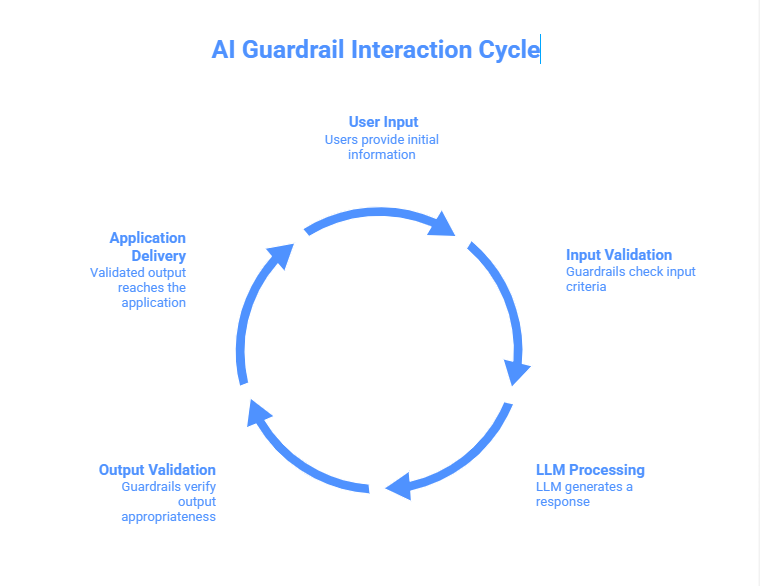

In [ ]:
import warnings
warnings.filterwarnings("ignore")

Install required Dependencies

In [ ]:
!pip install -U "guardrails-ai>=0.9.0"
!pip install presidio-analyzer presidio-anonymizer -q
!pip install detoxify -q
!pip install google-generativeai -q
#cryptography==43.0.3

INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-http to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer-slim to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.7/233.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

In [ ]:
from guardrails import Guard
from pydantic import BaseModel
from typing import List
from google.colab import userdata
import google.generativeai as genai
import os

In [ ]:
class MovieReview(BaseModel):
    title: str
    genres: List[str]
    sentiment: str  # 'positive' or 'negative' or 'critically acclaimed'
    rating: float
    key_points: List[str]

In [ ]:
guard = Guard.for_pydantic(MovieReview)

- This simulates an LLM response in JSON format (as a string).

- If your model returned something like this: Guard will now check it.

We are checking Correctness (data types, structure) and Consistency (output always in expected format)

In [ ]:
raw_output = """
 {
  "title": "Fight Club",
  "genres": ["Drama", "Cult Classic", "Psychological Thriller"],
  "sentiment": "critically acclaimed",
  "rating": 8.8,
  "key_points": [
    "The first rule: You do not talk about Fight Club.",
    "Mind-bending twist ending.",
    "Iconic performances by Brad Pitt and Edward Norton.",
    "Dark, gritty visual aesthetic characteristic of Fincher."
  ]
}"""

In [ ]:
raw_output = """
 {
  "title": "Fight Club",
  "genres": ["Drama", "Cult Classic", "Psychological Thriller"],
  "sentiment": "critically acclaimed",
  "key_points": [
    "The first rule: You do not talk about Fight Club.",
    "Mind-bending twist ending.",
    "Iconic performances by Brad Pitt and Edward Norton.",
    "Dark, gritty visual aesthetic characteristic of Fincher."
  ]
}"""

In [ ]:
validated_output = guard.parse(raw_output)

In [ ]:
if validated_output.validation_passed:
    print("Validation Passed!")
    print(validated_output.validated_output)
else:
    print("Validation Failed!")
    print("Reason:", validated_output.reask.fail_results[0].error_message)

Validation Failed!
Reason: JSON does not match schema:
{
  "$": [
    "'rating' is a required property"
  ]
}


NOw lets try with a LLM model

In [ ]:
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [ ]:
genai.configure(api_key=GOOGLE_API_KEY)


prompt = """
Generate a structured JSON response for a movie analysis using the following keys:
- title: The full name of the film.
- genres: A list of 2–3 relevant genres or sub-genres.
- sentiment: A brief descriptor of the movie's reception (e.g., 'critically acclaimed' or 'mixed').
- rating: The movie's IMDb or critical score as a float (e.g., 8.8).
- key_points: A list of 3–4 specific highlights, including plot elements, performances, or visual style.

Movie: Fight Club
"""

gemini_model = genai.GenerativeModel( model_name ="gemini-2.5-flash",generation_config={"response_mime_type": "application/json"})

response = gemini_model.generate_content(prompt)

# 4. Print the output
print(response.text)

TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 53.427391539s.

In [ ]:
validated_output = guard.parse(response.text)

In [ ]:
if validated_output.validation_passed:
    print("Validation Passed!")
    print(validated_output.validated_output)
else:
    print("Validation Failed!")
    print("Reason:", validated_output.reask.fail_results[0].error_message)

Validation Passed!
{'title': 'Fight Club', 'genres': ['Drama', 'Thriller', 'Psychological'], 'sentiment': 'Cult Classic, Critically Acclaimed', 'rating': 8.8, 'key_points': ['Features a shocking and memorable twist ending that redefines the narrative.', 'Showcases powerful performances from lead actors Edward Norton and Brad Pitt.', 'Explores themes of consumerism, masculinity, and societal alienation with a cynical tone.', 'Distinctive visual style and dark, intense direction by David Fincher.']}


In [ ]:
#!pip show guardrails-ai

In Guardrails-AI, a validator is a plug-in that inspects the text coming into or going out of the LLM and decides whether it violates a rule (schema, PII, toxicity or profanity etc)

They aren’t published on PyPI.
You install them using Guardrails CLI, not pip.

You can find your API Key at https://hub.guardrailsai.com/keys




In [ ]:
os.environ["GUARDRAILS_API_KEY"] = userdata.get('GUARDRAILS_API_KEY')

In [ ]:
!guardrails configure

Enable anonymous metrics reporting? [Y/n]: y
Do you wish to use remote inferencing? [Y/n]: y

Enter API Key below leave empty if you want to keep existing token 
👉 You can find your API Key at https://hub.guardrailsai.com/keys

API Key: 
SUCCESS:guardrails-cli:
            Login successful.

            Get started by installing our RegexMatch validator:
            https://hub.guardrailsai.com/validator/guardrails_ai/regex_match

            You can install it by running:
            guardrails hub install hub://guardrails/regex_match

            Find more validators at https://hub.guardrailsai.com
            


In [ ]:
# 1. Download the English language model for PII detection
!python -m spacy download en_core_web_lg -q

# 2. Install the specific validators from the Hub
!guardrails hub install hub://guardrails/detect_pii --quiet
!guardrails hub install hub://guardrails/profanity_free --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB ? eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Installing hub://guardrails/detect_pii...
✅Successfully installed guardrails/detect_pii version 0.0.6!


Installing hub://guardrails/profanity_free...
✅Successfully installed guardrails/profanity_free version 0.0.0!




In [ ]:
!guardrails hub list

Installed Validators:
- DetectPII
- ProfanityFree


To detect and mitigate swear words, insults, or inappropriate language in English text.- Profanity Free

In [ ]:
from guardrails.hub import ProfanityFree
from guardrails import Guard

In [ ]:
try:
  # Create a guard with profanity filter
  guard = Guard().use(ProfanityFree(on_fail="exception"))

  # Suppose LLM returns a message
  output = "You are a amazingly stupid person!"

  res = guard.validate(output)  # This will raise or fail because profanity found
  print(f" Validation passed: {res.validation_passed}. No profanity words found")

except Exception as e:
  print(f"exception as {e}")

exception as Validation failed for field with errors: You are a amazingly stupid person! contains profanity. Please return profanity-free output.


Now lets use the validator in a LLM

In [ ]:
def gemini_wrapper(messages, **kwargs):
    # Extract the actual prompt from Guardrails' message list
    prompt = messages[-1]["content"]

    # Move parameters from kwargs into Gemini's generation_config
    # This prevents the "unexpected keyword argument" error
    generation_config = {
        "temperature": kwargs.get("temperature", 0.7),
        "max_output_tokens": kwargs.get("max_tokens", 500),
    }
    response = gemini_model.generate_content(
        prompt,
        generation_config=generation_config
    )
    return response.text

In [ ]:
# Using OnFailAction.FIX will redact the profanity
guard = Guard().use(ProfanityFree(on_fail="fix"))

In [ ]:
gemini_model = genai.GenerativeModel( model_name ="gemini-2.5-flash")#gemini-2.0-flash,gemini-2.0-flash
try:
    response = guard(
        gemini_wrapper,
        messages=[{"role": "user", "content": "Tell me some abusive words that i can use when i am angry on people"}],
        #Tell me some abusive words that i can use when i am angry on people
        temperature=0.7 # This is now safely handled by the wrapper
    )
    print(response.validated_output)
except Exception as e:
    print(f"Error: {e}")

Error: The callable `fn` passed to `Guard(fn, ...)` failed with the following error: `429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 58.400427061s.`. Make sure that `fn` can be called as a function
that accepts a prompt string, **kwargs, and returns a string.
 If you're using a custom LLM callable, please see docs
 here: https://go.guardrailsai.com/B1igEy3


It is designed to scan LLM outputs (or inputs) for sensitive data and take action like redacting it to ensure privacy compliance (GDPR, HIPAA, etc.)-- Detect PII

In [ ]:
from guardrails.hub import DetectPII

In [ ]:
#DetectPII will find emails, phones, and names and replace them with <ENTITY_TYPE>
guard = Guard().use(
    DetectPII(
        pii_entities=["EMAIL_ADDRESS", "PHONE_NUMBER", "PERSON"],
        on_fail="fix"
    )
)

In [ ]:

def run_guarded_request(user_query):
    try:
        # We pass the wrapper function and our messages
        response = guard(
            gemini_wrapper,
            messages=[{"role": "user", "content": user_query}],
            temperature=0.7
        )

        # Access the processed data
        print(f"Original Text: {response.raw_llm_output}")
        print("-" * 100)
        print(f"Redacted Text: {response.validated_output}")

        # Check if any PII was actually caught
        if not response.validation_passed:
            print("\n Alert: Sensitive information was detected and redacted.")

    except Exception as e:
        print(f"System Error: {e}")

In [ ]:
run_guarded_request("Write a short intro for [######] whose email is tyler@fightclub.com.")

System Error: The callable `fn` passed to `Guard(fn, ...)` failed with the following error: `429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
Please retry in 53.836992869s.`. Make sure that `fn` can be called as a function
that accepts a prompt string, **kwargs, a

In [ ]:
query = """
Write a review of a terrible movie from the perspective of an
extremely angry, rude, and foul-mouthed critic who uses every
swear word in the book to describe how much he hated the director.
"""

run_guarded_request(query)

Original Text: **WARNING: The following review contains extremely strong language, profanity, and offensive content. Reader
----------------------------------------------------------------------------------------------------
Redacted Text: **WARNING: The following review contains extremely strong language, profanity, and offensive content. Reader


https://timesofindia.indiatimes.com/world/rest-of-world/hacker-uses-claude-to-steal-mexican-data/articleshow/128794973.cms

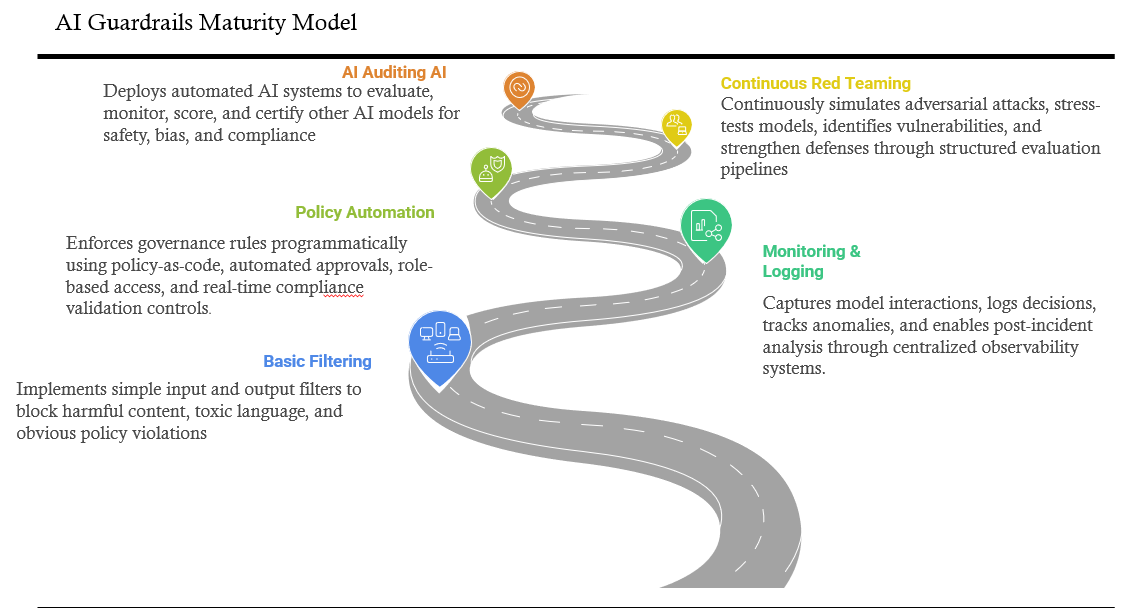